In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:


colunas_desejadas = ["Player", "Pos", "Squad", "Comp", "Gls", "Ast", "G+A", "Saves", "Tkl+Int", "KP"]
df = pd.read_csv("players_data_light-2024_2025.csv", usecols= colunas_desejadas)

df

,Player,Pos,Squad,Comp,Gls,Ast,G+A,KP,Tkl+Int,Saves
0,Max Aarons,DF,Bournemouth,eng Premier League,0,0,0,0,3,NaN
1,Max Aarons,"DF,MF",Valencia,es La Liga,0,0,0,1,4,NaN
2,Rodrigo Abajas,DF,Valencia,es La Liga,0,0,0,0,4,NaN
3,James Abankwah,"DF,MF",Udinese,it Serie A,0,0,0,0,5,NaN
4,Keyliane Abdallah,FW,Marseille,fr Ligue 1,0,0,0,0,1,NaN
...,...,...,...,...,...,...,...,...,...,...
2849,Edhy Zuliani,DF,Toulouse,fr Ligue 1,0,0,0,0,1,NaN
2850,Szymon Żurkowski,MF,Empoli,it Serie A,0,0,0,0,7,NaN
2851,Martin Ødegaard,MF,Arsenal,eng Premier League,3,8,11,63,25,NaN
2852,Milan Đurić,FW,Monza,it Serie A,4,1,5,5,3,NaN


In [ ]:
# Quantidade de jogadores por liga
print(df["Comp"].value_counts())

# Quantidad de jogadores por posição
print(df["Pos"].value_counts())

Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64
Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64


In [14]:
# Manipulação de string
s = "DF,MF"

s.split(",")[0]

df["Pos"] = df["Pos"].apply(lambda pos: pos.split(",")[0])

print(df["Pos"].value_counts())

Pos
DF    1022
MF     900
FW     720
GK     212
Name: count, dtype: int64


                  Player            Squad                Comp Pos  Gls
1691       Kylian Mbappé      Real Madrid          es La Liga  FW   31
2304       Mohamed Salah        Liverpool  eng Premier League  FW   29
1483  Robert Lewandowski        Barcelona          es La Liga  FW   27
1317          Harry Kane    Bayern Munich       de Bundesliga  FW   26
2201       Mateo Retegui         Atalanta          it Serie A  FW   25
1219      Alexander Isak    Newcastle Utd  eng Premier League  FW   23
1109      Erling Haaland  Manchester City  eng Premier League  FW   22
1093     Serhou Guirassy         Dortmund       de Bundesliga  FW   21
697      Ousmane Dembélé        Paris S-G          fr Ligue 1  FW   21
1060     Mason Greenwood        Marseille          fr Ligue 1  FW   21


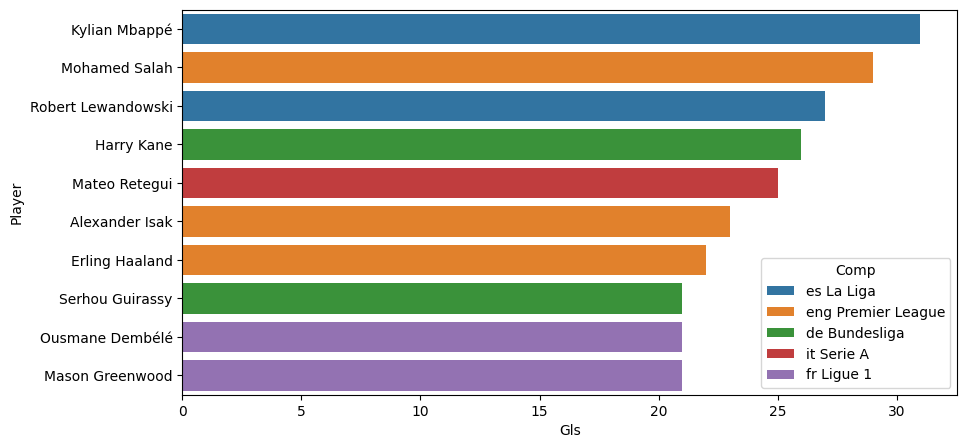

In [22]:
# TOP 10 artilheiros
top_scores = df.sort_values("Gls", ascending = False).head(10)[
    ["Player", "Squad", "Comp", "Pos", "Gls"]
]
print(top_scores)

# Vizualizando grafico
plt.figure(figsize=(10,5))
sns.barplot(data=top_scores, x="Gls", y="Player", hue="Comp")
plt.show()

               Player            Squad                Comp Pos  Ast
2304    Mohamed Salah        Liverpool  eng Premier League  FW   18
1960    Michael Olise    Bayern Munich       de Bundesliga  FW   15
2792     Lamine Yamal        Barcelona          es La Liga  FW   13
2779    Florian Wirtz       Leverkusen       de Bundesliga  MF   12
1830     Jacob Murphy    Newcastle Utd  eng Premier League  FW   12
829    Anthony Elanga  Nott'ham Forest  eng Premier League  FW   11
1064   Vincenzo Grifo         Freiburg       de Bundesliga  FW   11
2099    Gaëtan Perrin          Auxerre          fr Ligue 1  MF   11
541      Rayan Cherki             Lyon          fr Ligue 1  FW   11
238   Bradley Barcola        Paris S-G          fr Ligue 1  FW   10


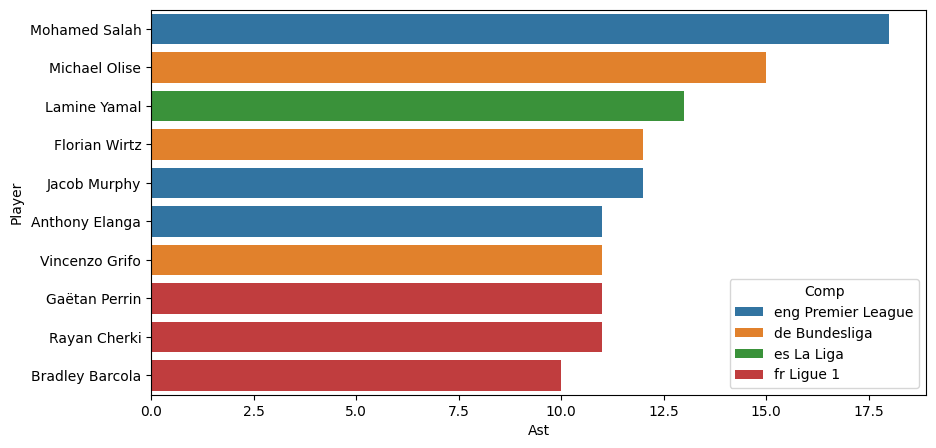

In [23]:
# TOP 10 assistentes
top_scores = df.sort_values("Ast", ascending = False).head(10)[
    ["Player", "Squad", "Comp", "Pos", "Ast"]
]
print(top_scores)

# Vizualizando grafico
plt.figure(figsize=(10,5))
sns.barplot(data=top_scores, x="Ast", y="Player", hue="Comp")
plt.show()

                  Player          Squad                Comp Pos  G+A
2304       Mohamed Salah      Liverpool  eng Premier League  FW   47
1317          Harry Kane  Bayern Munich       de Bundesliga  FW   35
1691       Kylian Mbappé    Real Madrid          es La Liga  FW   34
2201       Mateo Retegui       Atalanta          it Serie A  FW   33
1219      Alexander Isak  Newcastle Utd  eng Premier League  FW   29
1483  Robert Lewandowski      Barcelona          es La Liga  FW   29
1960       Michael Olise  Bayern Munich       de Bundesliga  FW   27
2177            Raphinha      Barcelona          es La Liga  FW   27
697      Ousmane Dembélé      Paris S-G          fr Ligue 1  FW   27
1693        Bryan Mbeumo      Brentford  eng Premier League  FW   27


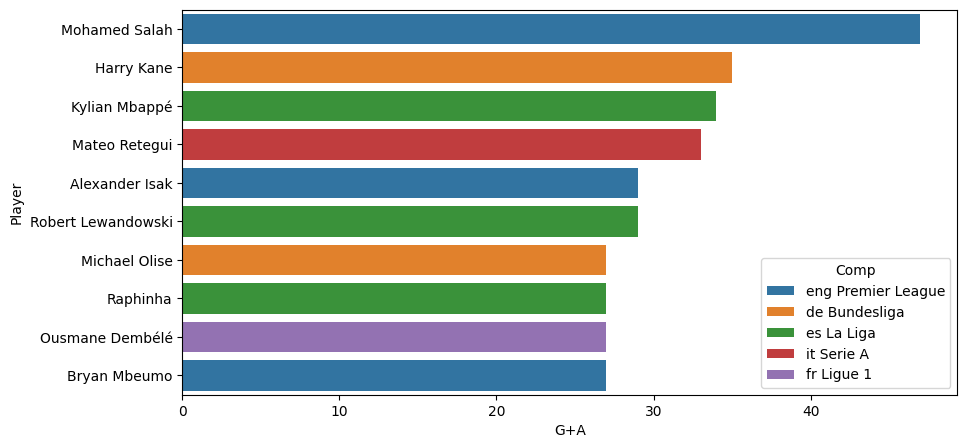

In [26]:
# Jogadores mais ofensivos - Com mais participações em gols
top_ofensivos = df.sort_values("G+A", ascending=False).head(10)[
    ["Player", "Squad", "Comp", "Pos", "G+A"]
]
print(top_ofensivos)

# Grafico
plt.figure(figsize=(10, 5))
sns.barplot(data = top_ofensivos, x = "G+A", y= "Player", hue = "Comp")
plt.show()

In [ ]:
# Liga com maior qualidade defensiva
df.groupby("Comp")["Tkl+Int"].mean().sort_values(ascending=False) # Media de botes e interceptações



Comp
eng Premier League    33.806620
es La Liga            30.745424
de Bundesliga         29.949187
fr Ligue 1            29.896926
it Serie A            27.015773
Name: Tkl+Int, dtype: float64

In [ ]:
# Liga com maior qualidade ofensiva
df.groupby("Comp")["G+A"].mean().sort_values(ascending=False) # Media gols e assistencias



Comp
eng Premier League    3.285714
de Bundesliga         3.262195
es La Liga            2.732113
fr Ligue 1            2.707052
it Serie A            2.523659
Name: G+A, dtype: float64

In [31]:
# Criando melhor time da temporada - baseada na formação 3-5-2

goleiros = df[df["Pos"] == "GK"]
defensores = df[df["Pos"] == "DF"]
meias = df[df["Pos"] == "MF"]
atacantes = df[df["Pos"] == "FW"]



melhor_goleiro = goleiros.sort_values("Saves", ascending =False).head(1)[
    ["Player", "Pos", "Squad", "Comp"]
]

melhores_defensores = defensores.sort_values("Tkl+Int", ascending =False).head(2)[
    ["Player", "Pos", "Squad", "Comp"]
]

melhores_meias = meias.sort_values("KP", ascending =False).head(5)[
    ["Player", "Pos", "Squad", "Comp"]
]

melhroes_atacantes = atacantes.sort_values("G+A", ascending =False).head(2)[
    ["Player", "Pos", "Squad", "Comp"]
]

dream_team = pd.concat([melhor_goleiro, melhores_defensores, melhores_meias, melhroes_atacantes])
print(dream_team)

               Player Pos           Squad                Comp
906      Mark Flekken  GK       Brentford  eng Premier League
1823     Daniel Muñoz  DF  Crystal Palace  eng Premier League
1161   Omar El Hilali  DF        Espanyol          es La Liga
200        Alex Baena  MF      Villarreal          es La Liga
891   Bruno Fernandes  MF  Manchester Utd  eng Premier League
2033      Cole Palmer  MF         Chelsea  eng Premier League
1356   Joshua Kimmich  MF   Bayern Munich       de Bundesliga
896    Enzo Fernández  MF         Chelsea  eng Premier League
2304    Mohamed Salah  FW       Liverpool  eng Premier League
1317       Harry Kane  FW   Bayern Munich       de Bundesliga
